# Практика 1

### Задача:
Необхомо решить задачу сегментации подростков по их интересам.

### Данные:

Набор данных представляет собой случайную выборку из 30 000 американских старшеклассников, у которых в 2006 году были профили в одной известной социальной сети. Данные были отобраны равномерно для четырёх разных возрастов (предполагаемый год окончания школы — 2006–2009).

* gradyear — год выпуска;
* gender — пол;
* age — возраст;
* friends — число друзей в социальной сети;
* basketball, football, soccer, softball, volleyball, swimming, cheerleading, baseball, tennis, sports, cute, sex, sexy, hot, kissed, dance, band, marching, music, rock, god, church, jesus, bible, hair, dress, blonde, mall, shopping, clothes, hollister, abercrombie, die, death, drunk, drugs (переменные с пятой по сороковую) — частота встречаемости соответствующих слов в сообщениях подростка.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

In [2]:
# Прочитаем данные
df_sns = pd.read_csv('Data/snsdata.csv')
df_sns = df_sns.iloc[:, 4:]
print(f'Размерность набора данных после удаления признаков: {df_sns.shape}')

Размерность набора данных после удаления признаков: (30000, 36)


In [3]:
# Нормализуем данные с помощью StandardScaler()
X = df_sns.values
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
print(f'Первое значение стандартизированной матрицы: {round(X_scaled[0][0], 2)}')

Первое значение стандартизированной матрицы: -0.33


In [4]:
# Реализуем алгоритм k-means
k_model = KMeans(n_clusters=9, random_state=42)
k_model.fit(X_scaled)
print(f'Значения инерции: {k_model.inertia_:.2f}')

df_sns.loc[:, 'label'] = k_model.labels_
df_sns.label.value_counts()

Значения инерции: 856276.70


label
1    19599
2     4284
0     2201
4      941
3      902
5      851
8      754
7      467
6        1
Name: count, dtype: int64

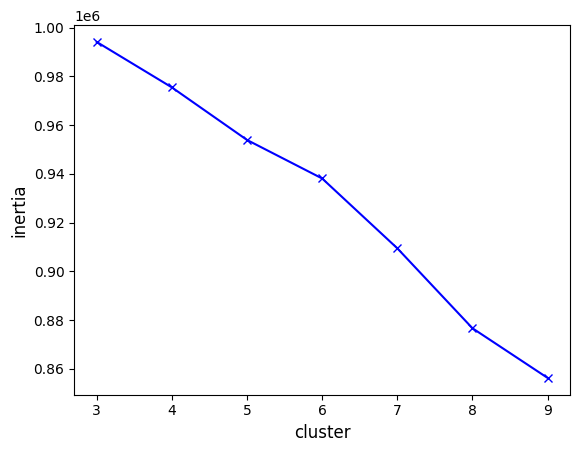

In [5]:
# Используем метод локтя для нахождения оптимального количества кластеров от 3 до 9
def get_inertia(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    inertia = k_means.inertia_
    return inertia
 
inertia = []
for cluster_num in range(3, 10):
    inertia.append(get_inertia(cluster_num, X_scaled))
 
plt.xlabel("cluster", fontsize=12)
plt.ylabel("inertia", fontsize=12)
plt.plot([i for i in range(3, 10)], inertia, 'xb-')

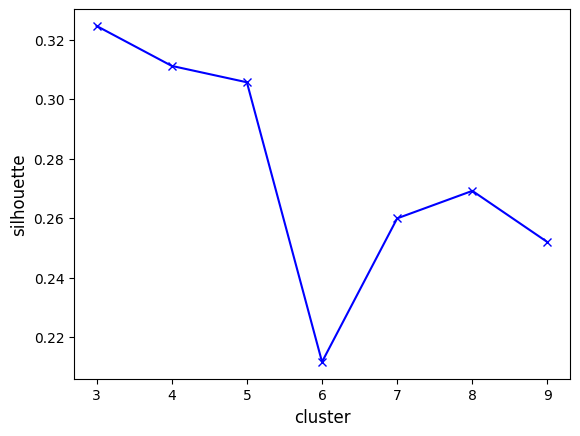

In [6]:
# Теперь попробуем найти количество кластеров с помощью коэффициента силуэта
def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.labels_, metric='euclidean')
    return silhouette

silhouettes = []
for i in range(3, 10):
    silhouettes.append(get_silhouette(i, X_scaled))
    
plt.xlabel("cluster", fontsize=12)
plt.ylabel("silhouette", fontsize=12)
plt.plot([i for i in range(3, 10)], silhouettes, 'xb-')

In [7]:
# Сегментация на 3 кластера (по результатам выбора)
k_model = KMeans(n_clusters=3, random_state=42)
k_model.fit(X_scaled)
df_sns["cluster"] = k_model.labels_

# Анализ топ-10 слов для каждого кластера
cluster_keywords = {}

for cluster_num in sorted(df_sns["cluster"].unique()):
    cluster_data = df_sns[df_sns["cluster"] == cluster_num].drop(columns=["cluster"])
    cluster_mean = cluster_data.mean().sort_values(ascending=False)
    top_10_words = cluster_mean.head(10).index.tolist()
    cluster_keywords[cluster_num] = top_10_words
    
# Поиск общих ключевых слов для всех кластеров
common_keywords = set(cluster_keywords[0])
for words in cluster_keywords.values():
    common_keywords.intersection_update(words)

cluster_keywords, common_keywords

({np.int32(0): ['label',
   'music',
   'god',
   'dance',
   'band',
   'hair',
   'shopping',
   'cute',
   'rock',
   'soccer'],
  np.int32(1): ['label',
   'hair',
   'sex',
   'music',
   'kissed',
   'die',
   'rock',
   'god',
   'band',
   'dance'],
  np.int32(2): ['label',
   'music',
   'dance',
   'shopping',
   'god',
   'cute',
   'hair',
   'church',
   'basketball',
   'mall']},
 {'dance', 'god', 'hair', 'label', 'music'})

In [8]:
# EM-алгоритм (GaussianMixture) на 
model = GaussianMixture(n_components=3, random_state=42)
predictions = model.fit_predict(X)
np.unique(predictions, return_counts=True)

(array([0, 1, 2]), array([21744,  5219,  3037]))

In [9]:
df_sns = df_sns.drop(['cluster', 'label'], axis=1)

In [10]:
a = np.where(predictions == 2)

# Убираем служебные столбцы и анализируем только признаки с интересами
person_data = df_sns.iloc[a]
person_words = person_data.iloc[:, 4:]  # Оставляем только признаки-слова

# Определяем топ-3 слов
top_3_words = person_words.T.sort_values(by=person_words.index[0], ascending=False).head(3).index.tolist()
print(f"Топ-3 слова: {top_3_words}")

Топ-3 слова: ['hollister', 'mall', 'band']


# Практика

### Задача:

Cегментация клиентов-держателей карт с использованием изученных методов кластеризации.

### Данные:

В нашем распоряжении есть данные о 8950 держателях кредитных карт одного из банков Нью-Йорка:

- CUST_ID — идентификационный номер держателя карты;
- BALANCE — баланс, доступный для совершения покупок;
- BALANCEFREQUENCY — как часто обновляется показатель баланса (1 — часто, 0 — нечасто);
- PURCHASES — количество покупок, оплаченных со счёта;
- ONEOFFPURCHASES — максимальная сумма единовременной покупки;
- INSTALLMENTSPURCHASES — сумма покупок, сделанных в рассрочку;
- PURCHASESFREQUENCY — как часто в целом совершаются покупки (1 — часто, 0 — нечасто);
- ONEOFFPURCHASESFREQUENCY — частота совершения единовременных покупок (1 — часто, 0 — нечасто);
- PURCHASESINSTALLMENTSFREQUENCY — частота совершения покупок в рассрочку (1 — часто, 0 — нечасто);
- CASHADVANCEFREQUENCY — частота внесения авансовых платежей;
- CASHADVANCETRX — количество транзакций с авансовыми взносами;
- PURCHASESTRX — количество совершённых транзакций с покупками;
- CREDITLIMIT — кредитный лимит держателя карты;
- PAYMENTS — сумма платежей пользователя;
- MINIMUM_PAYMENTS — сумма минимального платежа пользователя;
- PRCFULLPAYMENT — выплаченный процент от полного платежа;
- TENURE — срок обслуживания кредитной карты.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [24]:
# Прочитаем данные
df_general = pd.read_csv('Data/cc_general.csv', index_col=False)
display(df_general.info())
display()
display(df_general.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

None

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [25]:
# Пропущенные значения
display(f'Количество пропусков в данных: {df_general.isnull().sum().sum()}')

'Количество пропусков в данных: 314'

In [26]:
# Заполняем пропуски средним арифметическим для пропущенных признаков
df_general = df_general.fillna(df_general.mean(numeric_only=True))

# Выводим среднее значение признака MINIMUM_PAYMENTS после заполнения пропусков
mean_min_payments = df_general['MINIMUM_PAYMENTS'].mean()
print(f"Среднее значение для признака MINIMUM_PAYMENTS: {mean_min_payments:.2f}")

Среднее значение для признака MINIMUM_PAYMENTS: 864.21


In [27]:
# Нормализуем данные
X = df_general.drop('CUST_ID', axis=1)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# Вывод значения
display(f'Первое значение первой строки нормализованной матрицы: {X_norm[0][0]:.2f}')

'Первое значение первой строки нормализованной матрицы: -0.73'

Теперь можем приступать к кластеризации. Начнём с самого простого и популярного метода — k-means.

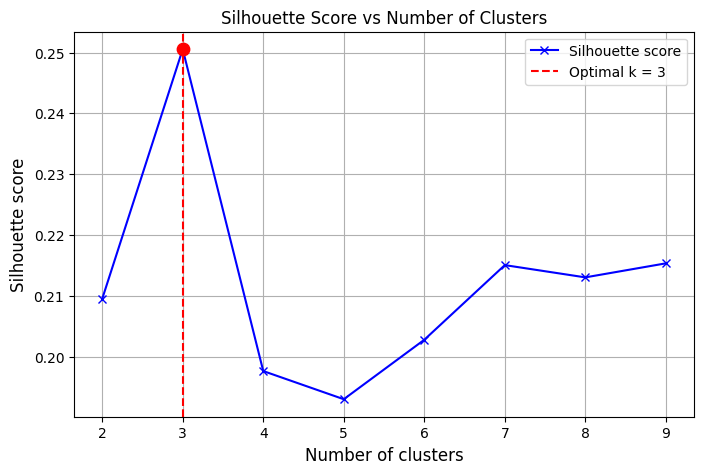

Оптимальное количество кластеров: 3 (силуэт: 0.251)


In [30]:
# Для начала найдем оптимальное количество кластеров с помощью коэфф силуэта
def get_silhouette(cluster_num, X):
    k_model =  KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_model.fit(X)
    silhouette = silhouette_score(X, k_model.labels_, metric='euclidean')
    return silhouette

silhouettes = []
cluster_range = range(2, 10) # Диапазон от 2 до 9 включительно

for i in cluster_range:
    silhouettes.append(get_silhouette(i, X_norm))

# Находим оптимальное количество кластеров
best_index = np.argmax(silhouettes)
best_k = cluster_range[best_index]
best_score = silhouettes[best_index]

# Визуализация
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouettes, 'xb-', label='Silhouette score')
plt.axvline(best_k, color='red', linestyle='--', label=f'Optimal k = {best_k}')
plt.scatter(best_k, best_score, color='red', s=80, zorder=5)
plt.xlabel("Number of clusters", fontsize=12)
plt.ylabel("Silhouette score", fontsize=12)
plt.title("Silhouette Score vs Number of Clusters")
plt.legend()
plt.grid(True)
plt.show()

# Выводим оптимальное количество кластеров
print(f"Оптимальное количество кластеров: {best_k} (силуэт: {best_score:.3f})")

In [31]:
# Кластеризация с помощью k-means с выбранными параметрами с помощью коэфф силуэта
k_model = KMeans(random_state=42, n_clusters=best_k, init='random')
k_model.fit(X_norm)

# Получаем метки кластеров
clusters = k_model.labels_

In [32]:
# Считаем количество объектов в каждом кластере
unique, counts = np.unique(clusters, return_counts=True)

# Находим количество самой малочисленной группе
min_counts_size = counts.min()

# Вывод
display(f'Самая малочисленная группа содержит {min_counts_size} человек(а).')

'Самая малочисленная группа содержит 1235 человек(а).'

Попробуем применить DBSCAN

In [38]:
# Кластеризация с помощью DBSCAN
dbscan_model = DBSCAN()
dbscan_model.fit(X_norm)

# Получаем метки кластеров
clusters = dbscan_model.labels_

In [39]:
# Количество кластеров (исключая "шум" — метку -1)
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

display(f'Количество выделенных кластеров (по-умолчанию): {n_clusters}')

'Количество выделенных кластеров (по-умолчанию): 38'

In [41]:
# Поскольку кластеров оказалось слишком много (параметры по-умолчанию), 
# мы с помощью цикла переберем eps и min_samples
best_score = -1
best_params = (None, None)

# Перебирает значения eps от 0.1 до 2.9 с шагом 0.2.
for eps in np.arange(0.1, 3, 0.2):
    # Перебирает min_samples от 1 до 17 с шагом 4.
    for min_samples in range(1, 20, 4):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_norm)
        
        # Пропускает случаи, где DBSCAN создал только 1 кластер или только шум.
        if len(set(labels)) <= 1 or (set(labels) == {-1}):
            continue
        
        # Считаем коэффициент силуэта
        score = silhouette_score(X_norm, labels)
        
        # Сохраняет параметры с максимальным силуэтом.
        if score > best_score:
                    best_score = score
                    best_params = (eps, min_samples)
# Вывод результатов      
best_eps = best_params[0]
best_min_samples = best_params[1]

print(f"Лучшая комбинация параметров: eps: {best_eps}, min_samples: {best_min_samples}")
print(f"Максимальный коэффициент силуэта: {best_score:.2f}")

Лучшая комбинация параметров: eps=2.900000000000001, min_samples=5
Максимальный коэффициент силуэта: 0.62


Теперь реализуем агломеративную иерархическую кластеризацию.

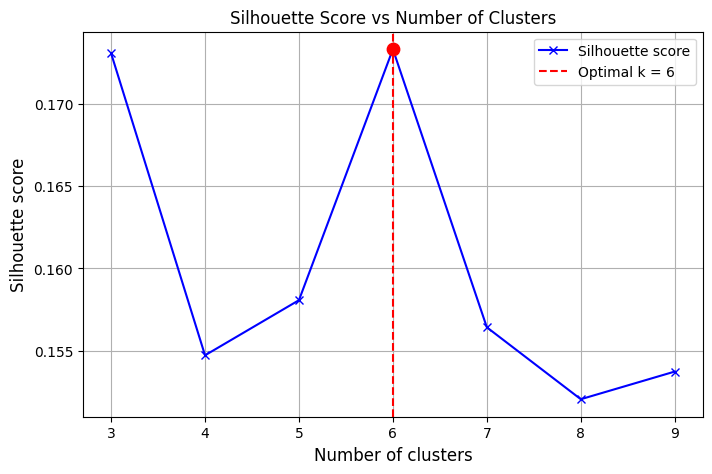

Оптимальное количество кластеров: 6 (силуэт: 0.173)


In [50]:
# Переберем количество кластеров в диапазоне от 3 до 9 включительно
def get_silhouette(cluster_num, X):
    ac_model =  AgglomerativeClustering(n_clusters=cluster_num)
    ac_model.fit(X)
    silhouette = silhouette_score(X, ac_model.labels_, metric='euclidean')
    return silhouette

silhouettes = []
cluster_range = range(3, 10) # Диапазон от 3 до 9 включительно

for i in cluster_range:
    silhouettes.append(get_silhouette(i, X_norm))

# Находим оптимальное количество кластеров
best_index = np.argmax(silhouettes)
best_k = cluster_range[best_index]
best_score = silhouettes[best_index]

# Визуализация
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouettes, 'xb-', label='Silhouette score')
plt.axvline(best_k, color='red', linestyle='--', label=f'Optimal k = {best_k}')
plt.scatter(best_k, best_score, color='red', s=80, zorder=5)
plt.xlabel("Number of clusters", fontsize=12)
plt.ylabel("Silhouette score", fontsize=12)
plt.title("Silhouette Score vs Number of Clusters")
plt.legend()
plt.grid(True)
plt.show()

# Выводим оптимальное количество кластеров
print(f"Оптимальное количество кластеров: {best_k} (силуэт: {best_score:.3f})")

In [51]:
# Агломеративная кластеризация с помощью с выбранными параметрами с помощью коэфф силуэта
ac_model =  AgglomerativeClustering(n_clusters=best_k)
ac_model.fit(X_norm)

# Получаем метки кластеров
clusters = ac_model.labels_

In [52]:
# Считаем количество объектов в каждом кластере
unique, counts = np.unique(clusters, return_counts=True)

# Находим количество самой многочисленной группе
max_counts_size = counts.max()

# Вывод
display(f'Самая многочисленная группа содержит {max_counts_size} человек(а).')

'Самая многочисленная группа содержит 3946 человек(а).'

Давайте визуализируем результаты кластеризации k-means, отобразив два признака — количество покупок и кредитный лимит:

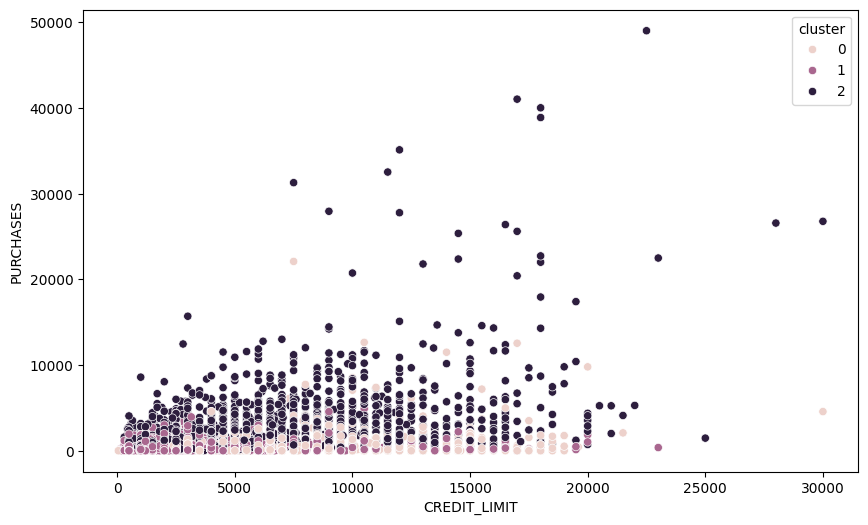

In [54]:
k_model = KMeans(n_clusters=3, random_state=42)
k_model.fit(X_norm)
df_general['cluster'] = k_model.labels_
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_general, x='CREDIT_LIMIT', y='PURCHASES', hue='cluster')
plt.show()

Мы видим, что практически все точки очень плотно сконцентрированы вместе, так что наши результаты с другими алгоритмами вполне предсказуемы.

С точки зрения интерпретации на графике явно выделяется группа тех, кто совершает много покупок по кредитной карте, и тех, кто совершает их меньше и имеет меньший кредитный лимит.

Но, разумеется, это лишь приблизительная интерпретация, ведь качественного разбиения с помощью большинства методов мы так и не получили, а кроме того, здесь мы видим лишь два признака из многих, на основе которых осуществлялась кластеризация.

Такая проблема с выделением кластеров часто возникает с данными, в которых много признаков. Для того чтобы её решить, можно, например, применять __снижение размерности__!!!